Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
Loaded points: (34752, 3)


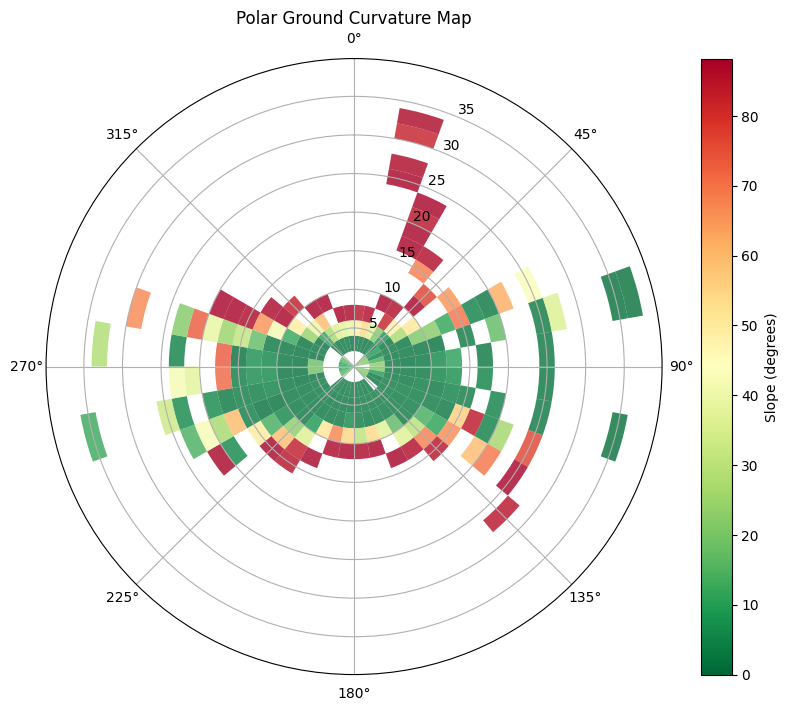

In [ ]:
#HOUDEN!!!!


import numpy as np
import open3d as o3d
import matplotlib.pyplot as plt

def load_nuscenes_bin(file_path):
    """Laad nuScenes pointcloud (.bin) bestand."""
    points = np.fromfile(file_path, dtype=np.float32)
    # nuScenes format: (x, y, z, intensity, ring_index)
    points = points.reshape(-1, 5)
    xyz = points[:, :3]
    return xyz

def compute_polar_grid_slopes(points, plane_model, 
                             r_step=5.0, 
                             theta_step_deg=15.0, 
                             distance_thresh=0.2, 
                             min_points=10, 
                             plane_thickness=0.1, 
                             plane_iterations=100):
    """
    Verdeelt de pointcloud in polaire cellen en berekent de helling per cel via RANSAC.
    """
    a, b, c, d = plane_model
    normal_ref = np.array([a, b, c])
    normal_ref = normal_ref / np.linalg.norm(normal_ref)

    # 1. Isoleer grondpunten
    distances = points @ normal_ref + d
    ground_points = points[np.abs(distances) < distance_thresh]
    
    if len(ground_points) == 0:
        print("Geen punten gevonden binnen de distance_thresh!")
        return []

    # 2. Omzetten naar Polair
    x = ground_points[:, 0]
    y = ground_points[:, 1]
    r = np.sqrt(x**2 + y**2)
    theta = np.arctan2(y, x)

    # Definieer bins
    r_bins = np.arange(0, r.max() + r_step, r_step)
    theta_bins = np.deg2rad(np.arange(-180, 180 + theta_step_deg, theta_step_deg))

    z_axis = np.array([0, 0, 1])
    results = []

    # 3. Itereer door cellen
    for i in range(len(r_bins) - 1):
        for j in range(len(theta_bins) - 1):
            mask = (
                (r >= r_bins[i]) & (r < r_bins[i+1]) &
                (theta >= theta_bins[j]) & (theta < theta_bins[j+1])
            )
            cell_pts = ground_points[mask]

            if len(cell_pts) < min_points:
                continue

            pcd = o3d.geometry.PointCloud()
            pcd.points = o3d.utility.Vector3dVector(cell_pts)

            try:
                # LOKALE RANSAC PLANE FITTING met jouw extra variabelen
                local_plane, _ = pcd.segment_plane(plane_thickness, 3, plane_iterations)
                la, lb, lc, _ = local_plane
                l_norm = np.array([la, lb, lc])
                l_norm /= np.linalg.norm(l_norm)

                # Ensure normal points 'up'
                if l_norm[2] < 0: l_norm = -l_norm

                slope = np.degrees(np.arccos(np.clip(np.dot(l_norm, z_axis), -1, 1)))
                
                # Store geometry for plotting
                results.append({
                    'r_mid': (r_bins[i] + r_bins[i+1]) / 2,
                    'theta_mid': (theta_bins[j] + theta_bins[j+1]) / 2,
                    'r_bounds': (r_bins[i], r_bins[i+1]),
                    'theta_bounds': (theta_bins[j], theta_bins[j+1]),
                    'slope': slope,
                    'normal': l_norm
                })
            except:
                continue
    return results

def visualize_polar_curvature(results, r_step, theta_step_deg):
    if not results: return

    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='polar')

    # Extract data
    slopes = np.array([res['slope'] for res in results])
    vmax = np.percentile(slopes, 95)
    cmap = plt.get_cmap('RdYlGn_r')

    # 4. Draw Annular Sectors
    for res in results:
        r0, r1 = res['r_bounds']
        t0, t1 = res['theta_bounds']
        
        # Draw the filled wedge
        ax.bar(t0, r1-r0, width=t1-t0, bottom=r0, 
               color=cmap(res['slope']/vmax), align='edge', alpha=0.8)

    # 5. Add orientation markers
    ax.set_theta_zero_location('N') # Set 0° (Forward/X) to North
    ax.set_theta_direction(-1)      # Clockwise
    
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(0, vmax))
    plt.colorbar(sm, ax=ax, label='Slope (degrees)')
    plt.title("Polar Ground Curvature Map")
    plt.show()

# --- PARAMETERS ---
FILE_PATH = r'C:\Users\Lars Wissink\OneDrive\Documenten\lars wissink\WB TU Delft\jaar 3\bep\pointcloud.bin'

R_STEP           = 2.0   
THETA_STEP       = 10.0  
DIST_THRESH      = 1.5   
MIN_POINTS_CELL  = 10    
PLANE_MODEL      = (0.001, 0.001, 1, 1.8786) 

PLANE_THICKNESS  = 0.2  
PLANE_ITERATIONS = 100

# --- UITVOERING ---

# 1. Punten laden
points = load_nuscenes_bin(FILE_PATH)
print('Loaded points:', points.shape)

# 2. Berekening
polar_results = compute_polar_grid_slopes(
    points, 
    plane_model=PLANE_MODEL,
    r_step=R_STEP, 
    theta_step_deg=THETA_STEP,
    distance_thresh=DIST_THRESH, 
    min_points=MIN_POINTS_CELL,
    plane_thickness=PLANE_THICKNESS, 
    plane_iterations=PLANE_ITERATIONS
)

# 3. Visualisatie
visualize_polar_curvature(polar_results, R_STEP, THETA_STEP)

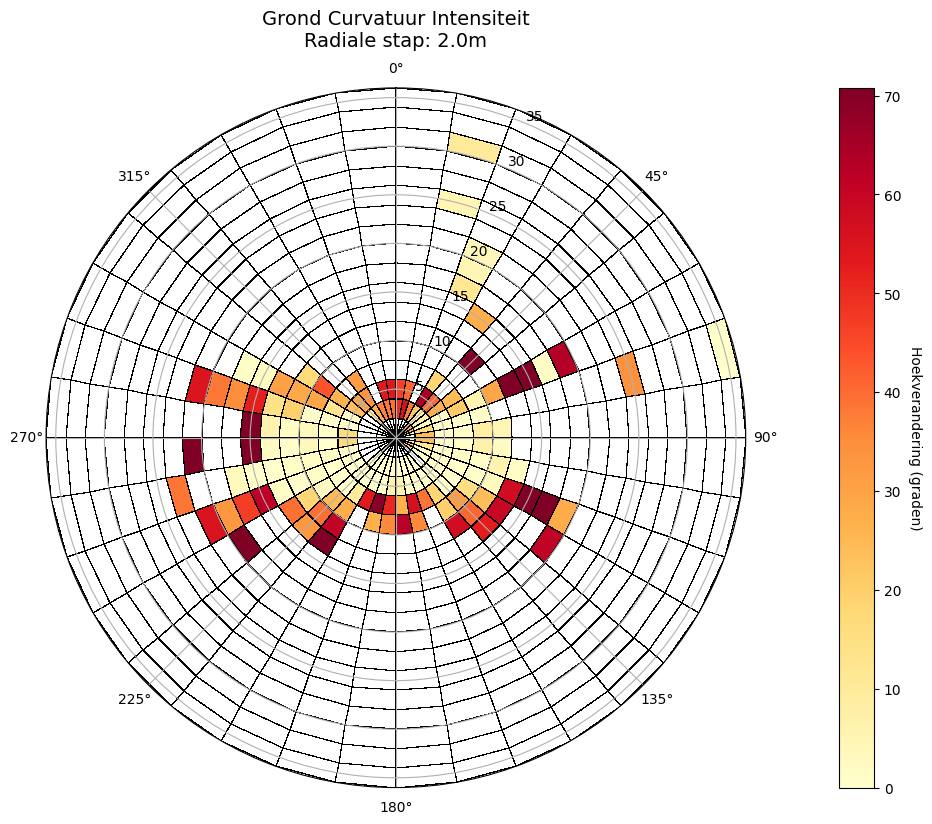

In [ ]:
#HOUDEN!!!!

import numpy as np
import matplotlib.pyplot as plt

def plot_direct_polar_curvature(results, r_step):
    """
    Plots the curvature intensity based on the angular difference 
    between normals in consecutive radial bins.
    """
    if not results:
        print("Geen resultaten gevonden.")
        return

    # 1. Organize data for quick lookup
    # Using sets to find unique boundaries, then sorting for the grid
    r_starts = sorted(list(set(res['r_bounds'][0] for res in results)))
    t_starts = sorted(list(set(res['theta_bounds'][0] for res in results)))
    t_ends = sorted(list(set(res['theta_bounds'][1] for res in results)))
    
    # Map (r_start, theta_start) to the normal vector
    data_map = {(res['r_bounds'][0], res['theta_bounds'][0]): res['normal'] for res in results}

    # 2. Build Curvature Matrix
    num_r = len(r_starts)
    num_t = len(t_starts)
    # Matrix dimensions: (radial_intervals - 1) x angular_bins
    curvature_matrix = np.full((num_r - 1, num_t), np.nan)

    for i in range(num_r - 1):
        r_curr = r_starts[i]
        r_next = r_starts[i+1]
        for j in range(num_t):
            t_curr = t_starts[j]
            
            n1 = data_map.get((r_curr, t_curr))
            n2 = data_map.get((r_next, t_curr))
            
            if n1 is not None and n2 is not None:
                # Calculate dot product and angle
                dot = np.clip(np.dot(n1, n2), -1.0, 1.0)
                diff = np.degrees(np.arccos(dot))
                
                # Use the acute angle (handle potential normal flips)
                if diff > 90:
                    diff = 180 - diff
                
                curvature_matrix[i, j] = diff

    # 3. Plotting
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='polar')
    
    # Standard orientation: North is 0°, clockwise
    ax.set_theta_zero_location('N')
    ax.set_theta_direction(-1)

    # Define the boundaries for pcolormesh
    t_boundaries = np.array(t_starts + [t_ends[-1]])
    r_boundaries = np.array(r_starts)

    mesh = ax.pcolormesh(
        t_boundaries, 
        r_boundaries, 
        curvature_matrix, 
        cmap='YlOrRd', 
        shading='flat', 
        edgecolor='black', 
        linewidth=0.1
    )
    
    # 4. Color Scaling
    valid_vals = curvature_matrix[~np.isnan(curvature_matrix)]
    if len(valid_vals) > 0:
        # Limit vmin/vmax to avoid outlier distortion
        vmax = np.percentile(valid_vals, 95)
        mesh.set_clim(0, max(vmax, 2.0))

    # Labels and Title
    cbar = plt.colorbar(mesh, ax=ax, pad=0.1)
    cbar.set_label('Hoekverandering (graden)', rotation=270, labelpad=15)
    
    ax.set_title(f"Grond Curvatuur Intensiteit\nRadiale stap: {r_step}m", pad=30, fontsize=14)
    
    plt.tight_layout()
    plt.show()

# Execution:
plot_direct_polar_curvature(polar_results, R_STEP)

C:\Users\Lars Wissink\AppData\Local\Temp\ipykernel_19492\3190337690.py:49: RuntimeWarning: overflow encountered in square
  dist_sq = np.sum(xyz**2, axis=1)


Frame opgehaald van /rslidar/helios_L op t=1762960979509941394
Totaal samengevoegde punten: 18833 van 1 sensoren.
--- Start Proces ---
Berekenen van hellingen...


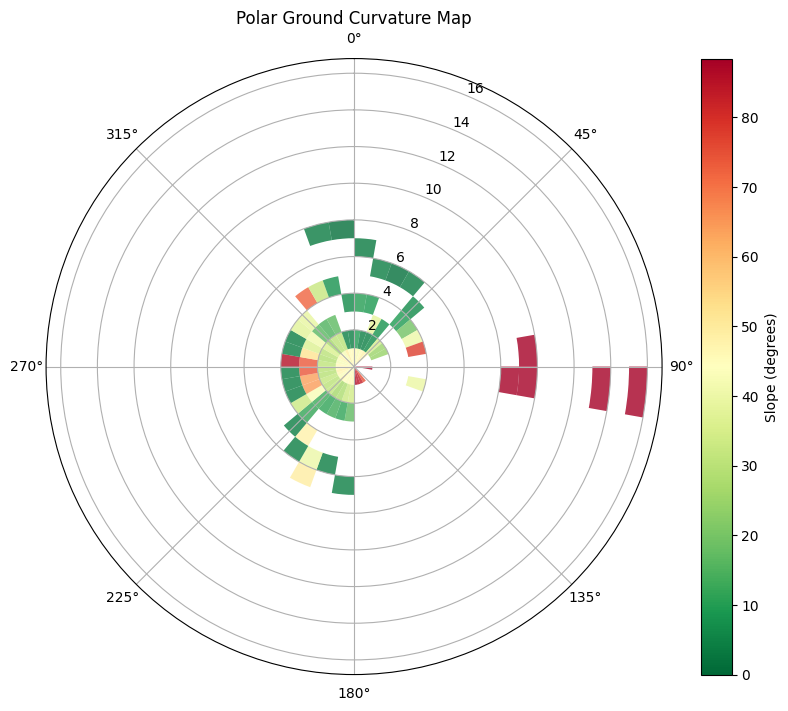

In [ ]:
#HOUDEN!!!

import numpy as np
import open3d as o3d
import matplotlib.pyplot as plt
from rosbags.highlevel import AnyReader
from pathlib import Path
from dateutil import parser
import struct

def get_all_lidars_merged(bag_path, target_time_str, sync_window_ms=50):
    """Zoekt en voegt punten van alle LiDAR sensors samen rond een tijdstip."""
    bag_path_obj = Path(bag_path)
    dt = parser.parse(target_time_str)
    target_ns = int(dt.timestamp() * 1e9)
    window_ns = sync_window_ms * 1_000_000
    
    merged_points = []
    found_topics = []

    with AnyReader([bag_path_obj]) as reader:
        # 1. Vind alle PointCloud2 connections
        connections = [x for x in reader.connections if 'PointCloud2' in x.msgtype]
        if not connections:
            print("Geen LiDAR topics gevonden!")
            return None, None

        # 2. Zoek per sensor naar het dichtstbijzijnde frame binnen het window
        for conn in connections:
            # We zoeken vanaf target_ns tot target_ns + window
            for _, timestamp, rawdata in reader.messages(connections=[conn], start=target_ns):
                # Controleer of we niet te ver buiten het window zitten
                if abs(timestamp - target_ns) > window_ns:
                    break 
                
                msg = reader.deserialize(rawdata, conn.msgtype)
                
                # Punten extractie (jouw bestaande logica)
                point_step = msg.point_step
                num_floats = point_step // 4
                raw_floats = np.frombuffer(msg.data, dtype=np.float32)
                
                total_pts = len(raw_floats) // num_floats
                points = raw_floats[:total_pts * num_floats].reshape(-1, num_floats)
                xyz = points[:, :3]
                
                # Cleaning
                xyz = xyz[np.all(np.isfinite(xyz), axis=1)]
                dist_sq = np.sum(xyz**2, axis=1)
                xyz = xyz[dist_sq < 20**2] # Max range filter

                if len(xyz) > 0:
                    merged_points.append(xyz)
                    found_topics.append(conn.topic)
                    print(f"Frame opgehaald van {conn.topic} op t={timestamp}")
                
                # We hebben het eerste frame voor deze sensor gevonden, stop voor deze sensor
                break

    if not merged_points:
        print("Geen punten gevonden binnen het tijdvenster.")
        return None, None

    # 3. Samenvoegen tot één grote numpy array
    all_xyz = np.vstack(merged_points)
    print(f"Totaal samengevoegde punten: {len(all_xyz)} van {len(found_topics)} sensoren.")
    return all_xyz, target_ns



# --- GEBRUIK ---
# Paden en Tijd
MCAP_FILE_PATH= r"C:\rosbag_0.mcap"
TARGET_TIME    = "2025-11-12 4:22:59.461 PM +01"

# Parameters
PLANE_MODEL      = (0, 0, 1, 1) # (a, b, c, d)
R_STEP           = 1.0
THETA_STEP       = 10.0
DIST_THRESH      = 1.0 
PLANE_THICKNESS  = 0.05
PLANE_ITERATIONS = 50

points, found_ts = get_all_lidars_merged(MCAP_FILE_PATH, TARGET_TIME)

if points is not None:
    # Je bestaande analyse functies...
    pass

# START
print("--- Start Proces ---")

if points is not None:
    print("Berekenen van hellingen...")
    analysis_results = compute_polar_grid_slopes(
        points, PLANE_MODEL, R_STEP, THETA_STEP, 
        DIST_THRESH, 10, PLANE_THICKNESS, PLANE_ITERATIONS
    )
    visualize_polar_curvature(analysis_results, R_STEP, THETA_STEP)
else:
    print("Kan frame niet laden.")

--- Start Proces ---
Zoeken naar tijdstip (NS): 1762960978460999936
Geselecteerd topic: /rslidar/M1P_deskewed
Gevonden frame op bag-tijd: 1762960978527071919
Aantal punten in frame: 21336
Berekenen van hellingen...


C:\Users\Lars Wissink\AppData\Local\Temp\ipykernel_19492\2476443812.py:59: RuntimeWarning: overflow encountered in square
  dist_sq = np.sum(xyz**2, axis=1)


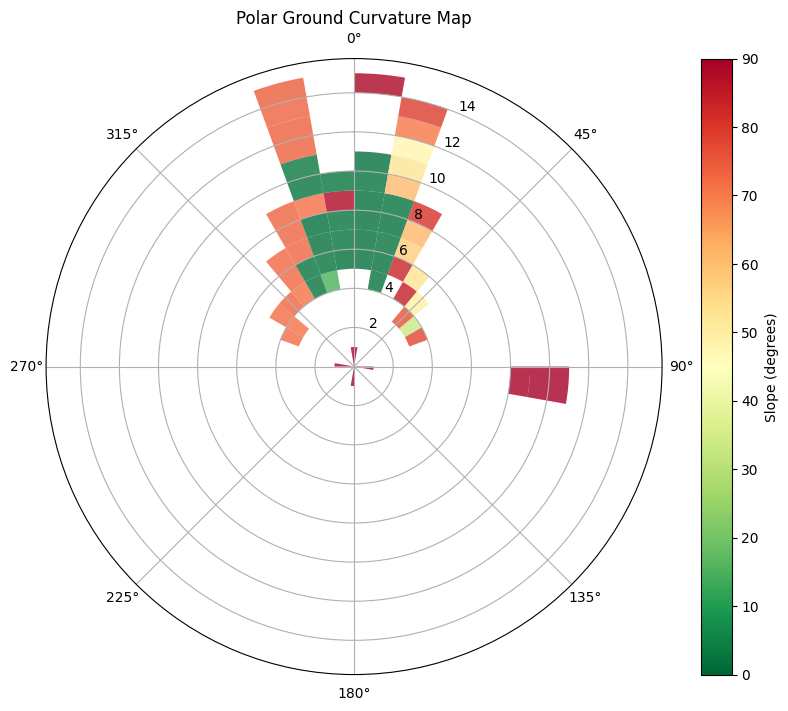

In [ ]:
#HOUDEN!!!

import numpy as np
import open3d as o3d
import matplotlib.pyplot as plt
from rosbags.highlevel import AnyReader
from pathlib import Path
from dateutil import parser
import struct

# --- 1. DATA LADEN UIT MCAP ---

def get_lidar_by_timestamp(bag_path, target_time_str, topic_name=None):
    """Zoekt het dichtstbijzijnde LiDAR frame op basis van een timestamp string."""
    bag_path_obj = Path(bag_path)
    
    # Zet de tijd-string om naar nanoseconden (Unix epoch)
    dt = parser.parse(target_time_str)
    target_ns = int(dt.timestamp() * 1e9)
    print(f"Zoeken naar tijdstip (NS): {target_ns}")

    with AnyReader([bag_path_obj]) as reader:
        # Automatisch topic selecteren als er geen is opgegeven
        if topic_name is None:
            connections = [x for x in reader.connections if 'PointCloud2' in x.msgtype]
            if not connections: 
                print("Geen PointCloud2 topics gevonden!")
                return None, None
            connection = connections[0]
            print(f"Geselecteerd topic: {connection.topic}")
        else:
            connections = [x for x in reader.connections if x.topic == topic_name]
            if not connections: 
                print(f"Topic {topic_name} niet gevonden!")
                return None, None
            connection = connections[0]

        try:
            # We gebruiken 'start' om direct naar de juiste tijd te springen
            for conn, timestamp, rawdata in reader.messages(connections=[connection], start=target_ns):
                msg = reader.deserialize(rawdata, conn.msgtype)
                
                # Punten extraheren uit bytes
                point_step = msg.point_step
                num_floats_per_point = point_step // 4
                raw_floats = np.frombuffer(msg.data, dtype=np.float32)
                
                # Voorkom reshape errors door alleen volledige punten te pakken
                total_complete_points = len(raw_floats) // num_floats_per_point
                clean_floats = raw_floats[:total_complete_points * num_floats_per_point]
                points = clean_floats.reshape(-1, num_floats_per_point)
                xyz = points[:, :3]

                # --- OPSCHONING (Cruciaal voor jouw foutmelding) ---
                # 1. Verwijder NaN en Inf waarden
                xyz = xyz[np.all(np.isfinite(xyz), axis=1)]
                
                # 2. Verwijder extreme uitschieters (>200m) om geheugenfouten te voorkomen
                dist_sq = np.sum(xyz**2, axis=1)
                xyz = xyz[dist_sq < 15**2]

                if len(xyz) == 0:
                    print("Waarschuwing: Geen geldige punten overgebleven na filtering.")
                    continue

                print(f"Gevonden frame op bag-tijd: {timestamp}")
                print(f"Aantal punten in frame: {len(xyz)}")
                return xyz, timestamp
        except Exception as e:
            print(f"Fout tijdens het lezen: {e}")
            
    return None, None

# --- 2. ANALYSE FUNCTIE ---



# Paden en Tijd
MCAP_FILE_PATH = r"C:\rosbag_0.mcap"
TARGET_TIME    = "2025-11-12 4:22:58.461 PM +01"

# Parameters
PLANE_MODEL      = (0, 0, 1, 1) # (a, b, c, d)
R_STEP           = 1.0
THETA_STEP       = 10.0
DIST_THRESH      = 1.0 
PLANE_THICKNESS  = 0.05
PLANE_ITERATIONS = 50

# START
print("--- Start Proces ---")
points, found_ts = get_lidar_by_timestamp(MCAP_FILE_PATH, TARGET_TIME)

if points is not None:
    print("Berekenen van hellingen...")
    analysis_results = compute_polar_grid_slopes(
        points, PLANE_MODEL, R_STEP, THETA_STEP, 
        DIST_THRESH, 10, PLANE_THICKNESS, PLANE_ITERATIONS
    )
    visualize_polar_curvature(analysis_results, R_STEP, THETA_STEP)
else:
    print("Kan frame niet laden.")